# 09 - Synthetic benchmark v0.2: temporal and candidate validation

## tl;dr

This notebook checks whether the `v0_2_conditional_revision` benchmark is
ready for the next stage: running the existing linkage algorithms for
evaluation. It deliberately does **not** tune linkage scores, thresholds, or
candidate filters.

Acceptance criteria are defined before interpreting the output:

- temporal year-share total variation distance (TVD) <= 0.20;
- schema-by-year WMAE <= 3 percentage points;
- notice-type-by-year WMAE <= 5 percentage points;
- follow-up runway absolute error <= 3 percentage points for 12m and 24m;
- algorithm-scope candidate source count should be at least 80% of the
  scale-adjusted real Layer 1 source count;
- algorithm-scope zero-candidate error <= 5 percentage points;
- algorithm-scope p90 candidate-count error <= 5 candidates;
- algorithm-scope cap-reached rate <= 1 percentage point.

The temporal gate can pass with caveats. The candidate-environment gate is
the decisive readiness check for linkage algorithms because candidate
availability is an emergent output of the generator plus the real production
candidate code.


## Context & Methods

Sources:

- Real corpus: `data/interim/boamp_common_prepared.csv`
- Real Layer 1 sources: `data/processed/boamp_only/boamp_only_sources.csv`
- Real Layer 1 candidate pairs:
  `data/processed/boamp_only/boamp_only_candidate_pairs.csv`
- Synthetic benchmark:
  `data/processed/synthetic_benchmark/v0_2_conditional_revision/central_provisional/world_001/corruption_001`

The primary candidate check adapts `observed_notices.parquet` with
`boamp.synthetic.compatibility.adapt_observed_notices_to_sources`, filters to
the same source population as Layer 1 (`APPEL_OFFRE` and `DIGITAL_ICT`), and
then runs the unmodified production candidate generator
`boamp.linkage.candidates.generate_pairs_single_key`.

A secondary broad check runs the same candidate generator on all eligible
synthetic observed notices. That is a compatibility diagnostic only; it is not
the readiness criterion for the real linking algorithms.


## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boamp.config import load_config
from boamp.data.prepare import tag_digital_scope
from boamp.linkage.candidates import generate_pairs_single_key
from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from utils.text_clean import normalize_objet

setup_style()
cfg = load_config(PROJECT_ROOT)

BENCHMARK_VERSION = "v0_2_conditional_revision"
SCENARIO = "central_provisional"
PILOT_DIR = (
    PROJECT_ROOT
    / "data/processed/synthetic_benchmark"
    / BENCHMARK_VERSION
    / SCENARIO
    / "world_001/corruption_001"
)

REAL_PATH = PROJECT_ROOT / "data/interim/boamp_common_prepared.csv"
REAL_SOURCES_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_sources.csv"
REAL_PAIRS_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_candidate_pairs.csv"

OUT_TABLES = PROJECT_ROOT / "reports/tables/synthetic_benchmark" / BENCHMARK_VERSION
OUT_FIGURES = PROJECT_ROOT / "reports/figures/synthetic_benchmark" / BENCHMARK_VERSION
OUT_REPORT = PROJECT_ROOT / "reports/generated/synthetic_benchmark/v0_2_temporal_candidate_validation_report.md"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUT_REPORT.parent.mkdir(parents=True, exist_ok=True)

COLOR_REAL = "#2a78d6"
COLOR_SYN = "#eb6834"
COLOR_GRID = "#e3e2dd"
COLOR_PASS = "#0ca30c"
COLOR_WARN = "#fab219"
COLOR_FAIL = "#d03b3b"

ACCEPTANCE = {
    "year_share_tvd_max": 0.20,
    "schema_by_year_wmae_pp_max": 3.0,
    "notice_type_by_year_wmae_pp_max": 5.0,
    "followup_12m_24m_abs_pp_max": 3.0,
    "candidate_scaled_source_count_min_ratio": 0.80,
    "candidate_zero_abs_pp_max": 5.0,
    "candidate_p90_abs_count_max": 5.0,
    "candidate_cap_rate_pp_max": 1.0,
}
pd.DataFrame([ACCEPTANCE]).to_csv(OUT_TABLES / "temporal_candidate_acceptance_criteria.csv", index=False)
ACCEPTANCE

{'year_share_tvd_max': 0.2,
 'schema_by_year_wmae_pp_max': 3.0,
 'notice_type_by_year_wmae_pp_max': 5.0,
 'followup_12m_24m_abs_pp_max': 3.0,
 'candidate_scaled_source_count_min_ratio': 0.8,
 'candidate_zero_abs_pp_max': 5.0,
 'candidate_p90_abs_count_max': 5.0,
 'candidate_cap_rate_pp_max': 1.0}

## Data

In [2]:
observed = pd.read_parquet(PILOT_DIR / "observed_notices.parquet")
clean = pd.read_parquet(PILOT_DIR / "clean_notices.parquet")
relations = pd.read_parquet(PILOT_DIR / "true_relations.parquet")

observed["publication_date"] = pd.to_datetime(observed["publication_date"])
clean["publication_date_true"] = pd.to_datetime(clean["publication_date_true"])
relations["source_expected_end"] = pd.to_datetime(relations["source_expected_end"])
relations["target_start"] = pd.to_datetime(relations["target_start"])

real = pd.read_csv(
    REAL_PATH,
    usecols=[
        "notice_id",
        "publication_date",
        "publication_year",
        "publication_month",
        "schema_family",
        "notice_type_normalized",
        "cpv_division",
        "is_digital_scope",
    ],
    parse_dates=["publication_date"],
    low_memory=False,
)

real_sources = pd.read_csv(REAL_SOURCES_PATH, parse_dates=["publication_date", "estimated_end_date"])
real_pairs = pd.read_csv(REAL_PAIRS_PATH, parse_dates=["source_date", "candidate_date", "expected_end_date"])

metadata = json.loads((PILOT_DIR / "generation_metadata.json").read_text())
print("Synthetic observed notices:", len(observed))
print("Real prepared notices:", len(real))
print("Real Layer 1 sources:", len(real_sources))
print("Real Layer 1 candidate pairs:", len(real_pairs))
print("Generator:", metadata["generator_version"], "status:", metadata["validation_status"])

Synthetic observed notices: 9607
Real prepared notices: 84623
Real Layer 1 sources: 3380
Real Layer 1 candidate pairs: 10862
Generator: 0.2.0-conditional-revision status: PASS


## Results - Temporal Fidelity

In [3]:
def style_axes(ax, horizontal_grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if horizontal_grid:
        ax.grid(axis="y", color=COLOR_GRID, linewidth=0.9, zorder=0)
    else:
        ax.grid(axis="x", color=COLOR_GRID, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)


def distribution_comparison(real_keys, synthetic_keys, label):
    real_counts = real_keys.value_counts(dropna=False).sort_index()
    synthetic_counts = synthetic_keys.value_counts(dropna=False).sort_index()
    idx = sorted(set(real_counts.index) | set(synthetic_counts.index))
    out = pd.DataFrame(index=idx)
    out.index.name = label
    out["n_real"] = real_counts.reindex(idx, fill_value=0).astype(int)
    out["n_synthetic"] = synthetic_counts.reindex(idx, fill_value=0).astype(int)
    out["real_share"] = out["n_real"] / out["n_real"].sum()
    out["synthetic_share"] = out["n_synthetic"] / out["n_synthetic"].sum()
    out["signed_diff_pp"] = (out["synthetic_share"] - out["real_share"]) * 100
    out["abs_diff_pp"] = out["signed_diff_pp"].abs()
    return out.reset_index()


def conditional_share_table(real_df, syn_df, outer_col, category_col, label):
    rows = []
    outer_vals = sorted(set(real_df[outer_col].dropna()) | set(syn_df[outer_col].dropna()))
    for outer in outer_vals:
        real_group = real_df.loc[real_df[outer_col] == outer]
        syn_group = syn_df.loc[syn_df[outer_col] == outer]
        cats = sorted(set(real_group[category_col].dropna()) | set(syn_group[category_col].dropna()))
        for cat in cats:
            real_share = float((real_group[category_col] == cat).mean()) if len(real_group) else 0.0
            syn_share = float((syn_group[category_col] == cat).mean()) if len(syn_group) else 0.0
            rows.append(
                {
                    outer_col: outer,
                    category_col: cat,
                    "n_real_outer": len(real_group),
                    "n_synthetic_outer": len(syn_group),
                    "real_share": real_share,
                    "synthetic_share": syn_share,
                    "signed_diff_pp": (syn_share - real_share) * 100,
                    "abs_diff_pp": abs(syn_share - real_share) * 100,
                    "dimension": label,
                }
            )
    return pd.DataFrame(rows)


real_temporal = real.copy()
real_temporal["publication_year"] = real_temporal["publication_date"].dt.year
real_temporal["publication_month_period"] = real_temporal["publication_date"].dt.to_period("M").astype(str)

synthetic_temporal = observed.copy()
synthetic_temporal["publication_year"] = synthetic_temporal["publication_date"].dt.year
synthetic_temporal["publication_month_period"] = synthetic_temporal["publication_date"].dt.to_period("M").astype(str)

year_table = distribution_comparison(
    real_temporal["publication_year"],
    synthetic_temporal["publication_year"],
    "publication_year",
)
month_table = distribution_comparison(
    real_temporal["publication_month_period"],
    synthetic_temporal["publication_month_period"],
    "publication_month",
)
schema_year_table = conditional_share_table(
    real_temporal, synthetic_temporal, "publication_year", "schema_family", "schema_by_year"
)
type_year_table = conditional_share_table(
    real_temporal, synthetic_temporal, "publication_year", "notice_type_normalized", "notice_type_by_year"
)

for table, name in [
    (year_table, "temporal_year_share_comparison.csv"),
    (month_table, "temporal_month_share_comparison.csv"),
    (schema_year_table, "temporal_schema_by_year_comparison.csv"),
    (type_year_table, "temporal_notice_type_by_year_comparison.csv"),
]:
    table.to_csv(OUT_TABLES / name, index=False)


def tvd(table):
    return float(0.5 * (table["synthetic_share"] - table["real_share"]).abs().sum())


def weighted_wmae_pp(table):
    weights = table["n_real_outer"].replace(0, np.nan)
    return float((weights * table["abs_diff_pp"]).sum() / weights.sum())


temporal_summary = pd.DataFrame(
    [
        {
            "dimension": "year_share",
            "metric": "TVD",
            "value": tvd(year_table),
            "threshold": ACCEPTANCE["year_share_tvd_max"],
            "status": "PASS" if tvd(year_table) <= ACCEPTANCE["year_share_tvd_max"] else "NEEDS_REVISION",
        },
        {
            "dimension": "schema_by_year",
            "metric": "WMAE_pp",
            "value": weighted_wmae_pp(schema_year_table),
            "threshold": ACCEPTANCE["schema_by_year_wmae_pp_max"],
            "status": "PASS"
            if weighted_wmae_pp(schema_year_table) <= ACCEPTANCE["schema_by_year_wmae_pp_max"]
            else "NEEDS_REVISION",
        },
        {
            "dimension": "notice_type_by_year",
            "metric": "WMAE_pp",
            "value": weighted_wmae_pp(type_year_table),
            "threshold": ACCEPTANCE["notice_type_by_year_wmae_pp_max"],
            "status": "PASS"
            if weighted_wmae_pp(type_year_table) <= ACCEPTANCE["notice_type_by_year_wmae_pp_max"]
            else "NEEDS_REVISION",
        },
        {
            "dimension": "month_share",
            "metric": "TVD",
            "value": tvd(month_table),
            "threshold": 0.20,
            "status": "PASS" if tvd(month_table) <= 0.20 else "NEEDS_REVISION",
        },
    ]
)
temporal_summary.to_csv(OUT_TABLES / "temporal_summary_metrics.csv", index=False)
temporal_summary

,dimension,metric,value,threshold,status
0,year_share,TVD,0.148901,0.2,PASS
1,schema_by_year,WMAE_pp,0.244580,3.0,PASS
2,notice_type_by_year,WMAE_pp,3.981633,5.0,PASS
3,month_share,TVD,0.168835,0.2,PASS


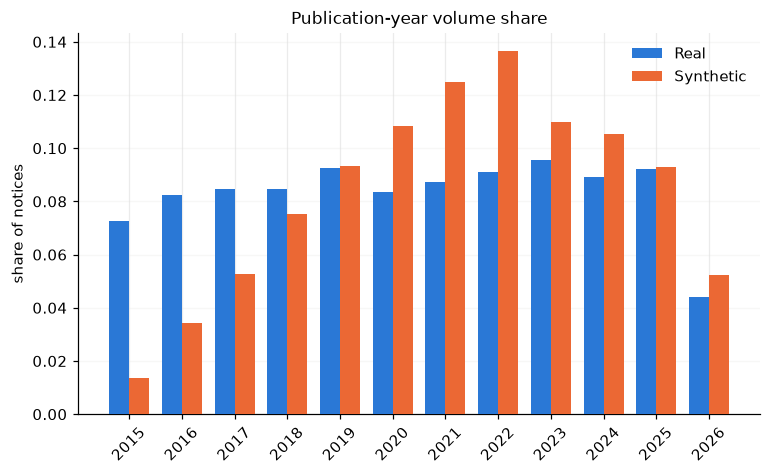

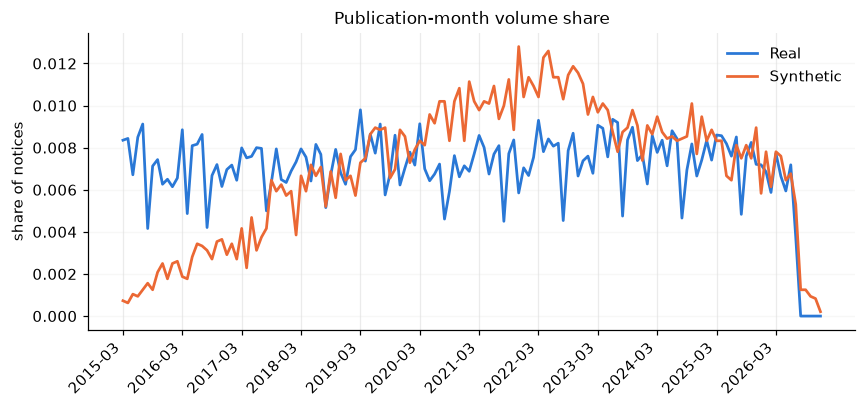

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(year_table))
width = 0.38
ax.bar(x - width / 2, year_table["real_share"], width, color=COLOR_REAL, label="Real", zorder=3)
ax.bar(x + width / 2, year_table["synthetic_share"], width, color=COLOR_SYN, label="Synthetic", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(year_table["publication_year"].astype(str), rotation=45)
ax.set_ylabel("share of notices")
ax.set_title("Publication-year volume share")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(OUT_FIGURES / "temporal_year_share_real_vs_synthetic.png", bbox_inches="tight", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(month_table["publication_month"], month_table["real_share"], color=COLOR_REAL, linewidth=1.8, label="Real")
ax.plot(month_table["publication_month"], month_table["synthetic_share"], color=COLOR_SYN, linewidth=1.8, label="Synthetic")
ax.set_xticks(month_table["publication_month"].iloc[::12])
ax.set_xticklabels(month_table["publication_month"].iloc[::12], rotation=45, ha="right")
ax.set_ylabel("share of notices")
ax.set_title("Publication-month volume share")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(OUT_FIGURES / "temporal_month_share_real_vs_synthetic.png", bbox_inches="tight", dpi=150)
plt.show()

## Results - Follow-up Runway

In [5]:
study_end_real = pd.to_datetime(real_sources["study_end_date"].dropna().iloc[0])
synthetic_followup = synthetic_temporal.copy()
real_followup = real_temporal.copy()

followup_rows = []
for months in [12, 24, 36, 60]:
    days = int(round(months * cfg.pipeline.run.month_days))
    real_rate = float(((study_end_real - real_followup["publication_date"]).dt.days >= days).mean())
    syn_rate = float(((study_end_real - synthetic_followup["publication_date"]).dt.days >= days).mean())
    threshold = ACCEPTANCE["followup_12m_24m_abs_pp_max"] if months in [12, 24] else 5.0
    followup_rows.append(
        {
            "horizon_months": months,
            "real_evaluable_rate": real_rate,
            "synthetic_evaluable_rate": syn_rate,
            "signed_diff_pp": (syn_rate - real_rate) * 100,
            "abs_diff_pp": abs(syn_rate - real_rate) * 100,
            "threshold_abs_pp": threshold,
            "status": "PASS" if abs(syn_rate - real_rate) * 100 <= threshold else "NEEDS_REVISION",
            "study_end_date": study_end_real.date().isoformat(),
        }
    )

followup_table = pd.DataFrame(followup_rows)
followup_table.to_csv(OUT_TABLES / "temporal_followup_runway_comparison.csv", index=False)
followup_table

,horizon_months,real_evaluable_rate,synthetic_evaluable_rate,signed_diff_pp,abs_diff_pp,threshold_abs_pp,status,study_end_date
0,12,0.916784,0.904549,-1.223509,1.223509,3.0,PASS,2026-07-13
1,24,0.825178,0.806287,-1.889047,1.889047,3.0,PASS,2026-07-13
2,36,0.732260,0.700947,-3.131233,3.131233,5.0,PASS,2026-07-13
3,60,0.550158,0.443947,-10.621064,10.621064,5.0,NEEDS_REVISION,2026-07-13


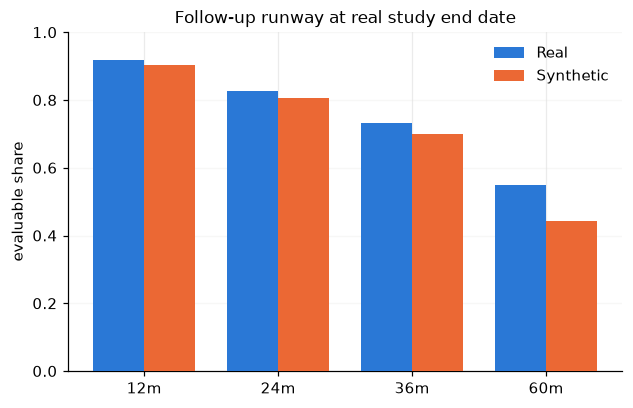

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(followup_table))
width = 0.38
ax.bar(x - width / 2, followup_table["real_evaluable_rate"], width, color=COLOR_REAL, label="Real", zorder=3)
ax.bar(x + width / 2, followup_table["synthetic_evaluable_rate"], width, color=COLOR_SYN, label="Synthetic", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([f"{m}m" for m in followup_table["horizon_months"]])
ax.set_ylabel("evaluable share")
ax.set_ylim(0, 1)
ax.set_title("Follow-up runway at real study end date")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(OUT_FIGURES / "temporal_followup_runway_real_vs_synthetic.png", bbox_inches="tight", dpi=150)
plt.show()

## Results - Candidate Environment

In [7]:
def attach_digital_scope(source_frame):
    out = source_frame.copy()
    out["objet_normalized"] = out["objet_clean"].map(normalize_objet)
    out["is_digital_scope"] = out.apply(
        lambda row: tag_digital_scope(row["cpv_division"], row["objet_normalized"], cfg),
        axis=1,
    )
    out["category_label"] = np.where(out["is_digital_scope"], "DIGITAL_ICT", "OTHER")
    return out


def candidate_count_frame(sources, pairs):
    eligible = sources.loc[sources["buyer_key_type"] != "MISSING"].copy()
    group_sizes = pairs.groupby("source_notice_id").size() if len(pairs) else pd.Series(dtype=int)
    keep_cols = [
        col
        for col in [
            "notice_id",
            "publication_date",
            "buyer_key_type",
            "schema_family",
            "notice_type_normalized",
            "cpv_division",
            "category_label",
        ]
        if col in eligible.columns
    ]
    out = eligible[keep_cols].copy()
    out["candidate_count"] = out["notice_id"].map(group_sizes).fillna(0).astype(int)
    return out


def candidate_summary(label, counts):
    return {
        "scope": label,
        "n_sources": int(len(counts)),
        "zero_candidate_rate": float((counts["candidate_count"] == 0).mean()) if len(counts) else np.nan,
        "mean_candidate_count": float(counts["candidate_count"].mean()) if len(counts) else np.nan,
        "median_candidate_count": float(counts["candidate_count"].median()) if len(counts) else np.nan,
        "p75_candidate_count": float(counts["candidate_count"].quantile(0.75)) if len(counts) else np.nan,
        "p90_candidate_count": float(counts["candidate_count"].quantile(0.90)) if len(counts) else np.nan,
        "p95_candidate_count": float(counts["candidate_count"].quantile(0.95)) if len(counts) else np.nan,
        "p99_candidate_count": float(counts["candidate_count"].quantile(0.99)) if len(counts) else np.nan,
        "max_candidate_count": int(counts["candidate_count"].max()) if len(counts) else 0,
        "cap_reached_rate": float((counts["candidate_count"] >= cfg.pipeline.candidates.max_candidates_per_source).mean()) if len(counts) else np.nan,
    }


real_counts = candidate_count_frame(real_sources, real_pairs)
real_summary = candidate_summary("real_layer1_algorithm_scope", real_counts)

synthetic_sources_all = attach_digital_scope(adapt_observed_notices_to_sources(observed))
synthetic_algorithm_scope = synthetic_sources_all.loc[
    (synthetic_sources_all["notice_type_normalized"] == "APPEL_OFFRE")
    & synthetic_sources_all["is_digital_scope"]
].copy()

synthetic_pairs_scope, synthetic_window_scope = generate_pairs_single_key(
    synthetic_algorithm_scope, cfg, verbose=True
)
synthetic_counts_scope = candidate_count_frame(synthetic_algorithm_scope, synthetic_pairs_scope)
synthetic_scope_summary = candidate_summary("synthetic_layer1_algorithm_scope", synthetic_counts_scope)

synthetic_pairs_broad, synthetic_window_broad = generate_pairs_single_key(
    synthetic_sources_all, cfg, verbose=True
)
synthetic_counts_broad = candidate_count_frame(synthetic_sources_all, synthetic_pairs_broad)
synthetic_broad_summary = candidate_summary("synthetic_all_observed_compatibility", synthetic_counts_broad)

candidate_summaries = pd.DataFrame([real_summary, synthetic_scope_summary, synthetic_broad_summary])
candidate_summaries["window_months"] = [
    cfg.pipeline.temporal_window.expected_value_months,
    synthetic_window_scope,
    synthetic_window_broad,
]
candidate_summaries.to_csv(OUT_TABLES / "candidate_environment_summary_metrics.csv", index=False)

for frame, name in [
    (real_counts, "candidate_counts_real_layer1_algorithm_scope.csv"),
    (synthetic_counts_scope, "candidate_counts_synthetic_layer1_algorithm_scope.csv"),
    (synthetic_counts_broad, "candidate_counts_synthetic_all_observed_compatibility.csv"),
]:
    frame.to_csv(OUT_TABLES / name, index=False)

candidate_summaries

Eligible sources: 354; median observed duration 12.0m -> temporal window 6m
Generated 54 Layer 1 candidate pairs (34 sources with >=1 candidate)
Eligible sources: 9607; median observed duration 12.0m -> temporal window 6m


Generated 33327 Layer 1 candidate pairs (4340 sources with >=1 candidate)


,scope,n_sources,zero_candidate_rate,mean_candidate_count,median_candidate_count,p75_candidate_count,p90_candidate_count,p95_candidate_count,p99_candidate_count,max_candidate_count,cap_reached_rate,window_months
0,real_layer1_algorithm_scope,3380,0.406805,3.213609,1.0,4.0,9.1,14.0,23.0,30,0.000888,6
1,synthetic_layer1_algorithm_scope,354,0.903955,0.152542,0.0,0.0,0.0,1.0,2.0,3,0.000000,6
2,synthetic_all_observed_compatibility,9607,0.548246,3.469033,0.0,2.0,16.0,27.0,30.0,30,0.040283,6


In [8]:
real_total = len(real)
synthetic_total = len(observed)
expected_scaled_real_sources = real_summary["n_sources"] * synthetic_total / real_total
source_count_ratio = synthetic_scope_summary["n_sources"] / expected_scaled_real_sources

candidate_validation_rows = [
    {
        "dimension": "algorithm_scope_source_count",
        "real_value": expected_scaled_real_sources,
        "synthetic_value": synthetic_scope_summary["n_sources"],
        "difference": synthetic_scope_summary["n_sources"] - expected_scaled_real_sources,
        "threshold": ACCEPTANCE["candidate_scaled_source_count_min_ratio"],
        "status": "PASS"
        if source_count_ratio >= ACCEPTANCE["candidate_scaled_source_count_min_ratio"]
        else "NEEDS_REVISION",
        "notes": "Synthetic APPEL_OFFRE and DIGITAL_ICT source count vs real Layer 1 count scaled to synthetic total notice volume.",
    },
    {
        "dimension": "algorithm_scope_zero_candidate_rate",
        "real_value": real_summary["zero_candidate_rate"],
        "synthetic_value": synthetic_scope_summary["zero_candidate_rate"],
        "difference": synthetic_scope_summary["zero_candidate_rate"] - real_summary["zero_candidate_rate"],
        "threshold": ACCEPTANCE["candidate_zero_abs_pp_max"] / 100,
        "status": "PASS"
        if abs(synthetic_scope_summary["zero_candidate_rate"] - real_summary["zero_candidate_rate"]) * 100
        <= ACCEPTANCE["candidate_zero_abs_pp_max"]
        else "NEEDS_REVISION",
        "notes": "Primary candidate readiness metric.",
    },
    {
        "dimension": "algorithm_scope_p90_candidate_count",
        "real_value": real_summary["p90_candidate_count"],
        "synthetic_value": synthetic_scope_summary["p90_candidate_count"],
        "difference": synthetic_scope_summary["p90_candidate_count"] - real_summary["p90_candidate_count"],
        "threshold": ACCEPTANCE["candidate_p90_abs_count_max"],
        "status": "PASS"
        if abs(synthetic_scope_summary["p90_candidate_count"] - real_summary["p90_candidate_count"])
        <= ACCEPTANCE["candidate_p90_abs_count_max"]
        else "NEEDS_REVISION",
        "notes": "Tail ambiguity in the actual Layer 1 source scope.",
    },
    {
        "dimension": "algorithm_scope_cap_reached_rate",
        "real_value": real_summary["cap_reached_rate"],
        "synthetic_value": synthetic_scope_summary["cap_reached_rate"],
        "difference": synthetic_scope_summary["cap_reached_rate"] - real_summary["cap_reached_rate"],
        "threshold": ACCEPTANCE["candidate_cap_rate_pp_max"] / 100,
        "status": "PASS"
        if synthetic_scope_summary["cap_reached_rate"] * 100 <= ACCEPTANCE["candidate_cap_rate_pp_max"]
        else "NEEDS_REVISION",
        "notes": "Cap pressure should be low before running linkage evaluation.",
    },
    {
        "dimension": "broad_compatibility_runs",
        "real_value": np.nan,
        "synthetic_value": len(synthetic_pairs_broad),
        "difference": np.nan,
        "threshold": np.nan,
        "status": "PASS" if len(synthetic_pairs_broad) > 0 else "NEEDS_REVISION",
        "notes": "Diagnostic only: production candidate code can consume all adapted observed notices.",
    },
]
candidate_validation = pd.DataFrame(candidate_validation_rows)
candidate_validation.to_csv(OUT_TABLES / "candidate_environment_validation_gate.csv", index=False)
candidate_validation

,dimension,real_value,synthetic_value,difference,threshold,status,notes
0,algorithm_scope_source_count,383.721447,354.000000,-29.721447,0.80,PASS,Synthetic APPEL_OFFRE and DIGITAL_ICT source c...
1,algorithm_scope_zero_candidate_rate,0.406805,0.903955,0.497150,0.05,NEEDS_REVISION,Primary candidate readiness metric.
2,algorithm_scope_p90_candidate_count,9.100000,0.000000,-9.100000,5.00,NEEDS_REVISION,Tail ambiguity in the actual Layer 1 source sc...
3,algorithm_scope_cap_reached_rate,0.000888,0.000000,-0.000888,0.01,PASS,Cap pressure should be low before running link...
4,broad_compatibility_runs,NaN,33327.000000,NaN,NaN,PASS,Diagnostic only: production candidate code can...


In [9]:
by_key_rows = []
for label, counts in [
    ("real_layer1_algorithm_scope", real_counts),
    ("synthetic_layer1_algorithm_scope", synthetic_counts_scope),
    ("synthetic_all_observed_compatibility", synthetic_counts_broad),
]:
    grouped = counts.groupby("buyer_key_type", dropna=False)["candidate_count"]
    table = grouped.agg(
        n_sources="size",
        mean_candidate_count="mean",
        median_candidate_count="median",
        p90_candidate_count=lambda s: s.quantile(0.90),
        zero_candidate_rate=lambda s: (s == 0).mean(),
    ).reset_index()
    table.insert(0, "scope", label)
    by_key_rows.append(table)

candidate_by_key = pd.concat(by_key_rows, ignore_index=True)
candidate_by_key.to_csv(OUT_TABLES / "candidate_environment_by_buyer_key_type.csv", index=False)
candidate_by_key

,scope,buyer_key_type,n_sources,mean_candidate_count,median_candidate_count,p90_candidate_count,zero_candidate_rate
0,real_layer1_algorithm_scope,NAME_FALLBACK,2506,3.394653,1.0,10.0,0.393057
1,real_layer1_algorithm_scope,RAW_SIRET,874,2.694508,1.0,9.0,0.446224
2,synthetic_layer1_algorithm_scope,NAME_FALLBACK,253,0.197628,0.0,1.0,0.877470
3,synthetic_layer1_algorithm_scope,RAW_SIREN,6,0.000000,0.0,0.0,1.000000
4,synthetic_layer1_algorithm_scope,RAW_SIRET,95,0.042105,0.0,0.0,0.968421
5,synthetic_all_observed_compatibility,NAME_FALLBACK,6491,5.022801,1.0,23.0,0.414728
6,synthetic_all_observed_compatibility,RAW_SIREN,211,0.014218,0.0,0.0,0.985782
7,synthetic_all_observed_compatibility,RAW_SIRET,2905,0.248193,0.0,1.0,0.814802


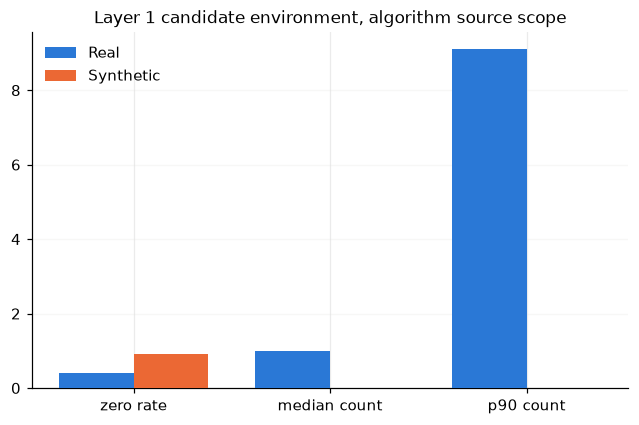

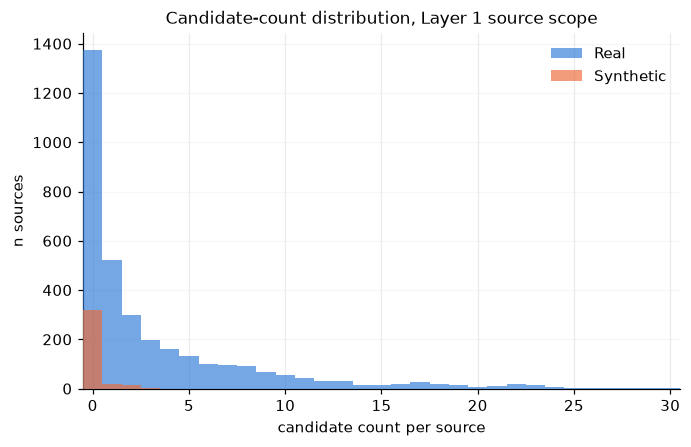

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
plot_summary = candidate_summaries.set_index("scope").loc[
    ["real_layer1_algorithm_scope", "synthetic_layer1_algorithm_scope"]
]
metrics = ["zero_candidate_rate", "median_candidate_count", "p90_candidate_count"]
x = np.arange(len(metrics))
width = 0.38
ax.bar(x - width / 2, plot_summary.loc["real_layer1_algorithm_scope", metrics], width, color=COLOR_REAL, label="Real", zorder=3)
ax.bar(x + width / 2, plot_summary.loc["synthetic_layer1_algorithm_scope", metrics], width, color=COLOR_SYN, label="Synthetic", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(["zero rate", "median count", "p90 count"])
ax.set_title("Layer 1 candidate environment, algorithm source scope")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(OUT_FIGURES / "candidate_environment_algorithm_scope_summary.png", bbox_inches="tight", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.2))
max_bin = cfg.pipeline.candidates.max_candidates_per_source
bins = np.arange(0, max_bin + 2) - 0.5
ax.hist(real_counts["candidate_count"], bins=bins, color=COLOR_REAL, alpha=0.65, label="Real", zorder=3)
ax.hist(synthetic_counts_scope["candidate_count"], bins=bins, color=COLOR_SYN, alpha=0.65, label="Synthetic", zorder=3)
ax.set_xlim(-0.5, max_bin + 0.5)
ax.set_xlabel("candidate count per source")
ax.set_ylabel("n sources")
ax.set_title("Candidate-count distribution, Layer 1 source scope")
ax.legend(frameon=False)
style_axes(ax)
fig.savefig(OUT_FIGURES / "candidate_count_distribution_algorithm_scope.png", bbox_inches="tight", dpi=150)
plt.show()

## Results - Temporal Truth Sanity Checks

In [11]:
successors = relations.loc[relations["relation_type"] != "NO_SUCCESSOR"].copy()
truth_rows = []
truth_rows.append(
    {
        "metric": "cycles",
        "value": len(relations),
        "notes": "Latent cycle count; synthetic-only structural check.",
    }
)
truth_rows.append(
    {
        "metric": "successor_relation_rate",
        "value": float(len(successors) / len(relations)),
        "notes": "Synthetic-only; no direct observed real truth baseline.",
    }
)
if len(successors):
    truth_rows.extend(
        [
            {
                "metric": "true_gap_median_months",
                "value": float(successors["true_gap_months"].median()),
                "notes": "Median gap from source expected end to target start.",
            },
            {
                "metric": "true_gap_p90_months",
                "value": float(successors["true_gap_months"].quantile(0.90)),
                "notes": "Tail should not be artificially locked to the 6-month candidate window.",
            },
            {
                "metric": "share_true_gaps_over_6m",
                "value": float((successors["true_gap_months"] > 6).mean()),
                "notes": "Checks separation between latent truth and candidate-window design.",
            },
        ]
    )

truth_sanity = pd.DataFrame(truth_rows)
truth_sanity.to_csv(OUT_TABLES / "temporal_truth_sanity_checks.csv", index=False)
truth_sanity

,metric,value,notes
0,cycles,6914.000000,Latent cycle count; synthetic-only structural ...
1,successor_relation_rate,0.292305,Synthetic-only; no direct observed real truth ...
2,true_gap_median_months,17.115637,Median gap from source expected end to target ...
3,true_gap_p90_months,28.416557,Tail should not be artificially locked to the ...
4,share_true_gaps_over_6m,0.890153,Checks separation between latent truth and can...


## Takeaways

In [12]:
temporal_gate_status = (
    "PASS"
    if (
        (temporal_summary["status"] == "PASS").all()
        and followup_table.loc[followup_table["horizon_months"].isin([12, 24]), "status"].eq("PASS").all()
    )
    else "NEEDS_REVISION"
)

candidate_gate_status = (
    "PASS"
    if candidate_validation.loc[
        candidate_validation["dimension"].isin(
            [
                "algorithm_scope_source_count",
                "algorithm_scope_zero_candidate_rate",
                "algorithm_scope_p90_candidate_count",
                "algorithm_scope_cap_reached_rate",
            ]
        ),
        "status",
    ].eq("PASS").all()
    else "NEEDS_REVISION"
)

overall_status = "SUPERSEDED_BY_V0_3_READINESS_ASSESSMENT"

freeze_gate = pd.DataFrame(
    [
        {
            "dimension": "temporal_validation",
            "status": temporal_gate_status,
            "notes": "Calendar/share checks plus 12m/24m follow-up runway.",
        },
        {
            "dimension": "candidate_environment_validation",
            "status": candidate_gate_status,
            "notes": "Production Layer 1 candidate generator on APPEL_OFFRE + DIGITAL_ICT source scope.",
        },
        {
            "dimension": "linkage_algorithm_readiness",
            "status": overall_status,
            "notes": "Historical v0.2 diagnostic. Use the v0.3 five-level readiness assessment for current permitted uses.",
        },
    ]
)
freeze_gate.to_csv(OUT_TABLES / "temporal_candidate_freeze_gate.csv", index=False)

def fmt_pct(x):
    return f"{x * 100:.1f}%"

def fmt_pp(x):
    return f"{x:.1f}pp"

report = f"""# Synthetic benchmark v0.2 temporal and candidate validation

## Result

**Legacy freeze-gate status: {overall_status}.**

This v0.2 notebook is retained as historical diagnostic evidence. It does not
define current benchmark readiness; use the v0.3 five-level readiness
assessment for permitted uses and prohibited claims.

Temporal validation status: **{temporal_gate_status}**.
Candidate-environment validation status: **{candidate_gate_status}**.

This means the v0.2 benchmark should **not yet be used as the main benchmark
for linkage-algorithm evaluation**. The candidate code runs, but the
algorithm-scope candidate environment does not yet resemble the real Layer 1
source universe closely enough.

## Temporal findings

- Publication-year TVD: {temporal_summary.loc[temporal_summary.dimension == 'year_share', 'value'].iloc[0]:.3f}
  against threshold {ACCEPTANCE['year_share_tvd_max']:.2f}.
- Schema-by-year WMAE: {temporal_summary.loc[temporal_summary.dimension == 'schema_by_year', 'value'].iloc[0]:.2f}pp.
- Notice-type-by-year WMAE: {temporal_summary.loc[temporal_summary.dimension == 'notice_type_by_year', 'value'].iloc[0]:.2f}pp.
- Follow-up runway 12m/24m differences:
  {fmt_pp(followup_table.loc[followup_table.horizon_months == 12, 'signed_diff_pp'].iloc[0])} /
  {fmt_pp(followup_table.loc[followup_table.horizon_months == 24, 'signed_diff_pp'].iloc[0])}.
- Longer 60m follow-up is underrepresented by
  {fmt_pp(followup_table.loc[followup_table.horizon_months == 60, 'signed_diff_pp'].iloc[0])};
  treat long-horizon survival checks cautiously until the date distribution is
  revised.

## Candidate-environment findings

- Real Layer 1 source count: {real_summary['n_sources']:,}.
- Synthetic Layer 1 source-scope count: {synthetic_scope_summary['n_sources']:,}
  versus {expected_scaled_real_sources:.1f} expected after scaling real source
  count to synthetic total volume; ratio = {source_count_ratio:.2f}.
- Zero-candidate rate: real {fmt_pct(real_summary['zero_candidate_rate'])},
  synthetic {fmt_pct(synthetic_scope_summary['zero_candidate_rate'])}.
- P90 candidates per source: real {real_summary['p90_candidate_count']:.0f},
  synthetic {synthetic_scope_summary['p90_candidate_count']:.0f}.
- Cap-reached rate: real {fmt_pct(real_summary['cap_reached_rate'])},
  synthetic {fmt_pct(synthetic_scope_summary['cap_reached_rate'])}.
- Broad all-observed compatibility check: production candidate generation ran
  and produced {len(synthetic_pairs_broad):,} pairs, but that broad universe is
  diagnostic only and is not the algorithm-readiness criterion.

## Interpretation

The conditional generator revision solved the earlier field-fidelity gate, but
the benchmark still needs a temporal/candidate revision before linkage
algorithm evaluation. The main issue is not a linkage-score problem; it is the
observable source universe and candidate environment entering the existing
candidate generator.

Recommended next work:

1. Preserve the now-acceptable `APPEL_OFFRE` + `DIGITAL_ICT` source count, but
   revise within-scope recurrence so enough sources have same-buyer future
   candidates near their expected end dates.
2. Calibrate buyer-key reuse, digital CPV/text assignment, and duration/end-date
   co-occurrence inside the algorithm source scope without using linkage scores
   or thresholds as tuning targets.
3. Rerun this notebook and require the candidate-environment gate to pass
   before running linkage-score comparisons.

## Saved artifacts

- `notebooks/09_synthetic_temporal_candidate_validation.ipynb`
- `reports/tables/synthetic_benchmark/v0_2_conditional_revision/temporal_candidate_freeze_gate.csv`
- `reports/tables/synthetic_benchmark/v0_2_conditional_revision/candidate_environment_validation_gate.csv`
- `reports/generated/synthetic_benchmark/v0_2_temporal_candidate_validation_report.md`
"""

OUT_REPORT.write_text(report)
print(report)
freeze_gate

# Synthetic benchmark v0.2 temporal and candidate validation

## Result

**Legacy freeze-gate status: SUPERSEDED_BY_V0_3_READINESS_ASSESSMENT.**

This v0.2 notebook is retained as historical diagnostic evidence. It does not
define current benchmark readiness; use the v0.3 five-level readiness
assessment for permitted uses and prohibited claims.

Temporal validation status: **PASS**.
Candidate-environment validation status: **NEEDS_REVISION**.

This means the v0.2 benchmark should **not yet be used as the main benchmark
for linkage-algorithm evaluation**. The candidate code runs, but the
algorithm-scope candidate environment does not yet resemble the real Layer 1
source universe closely enough.

## Temporal findings

- Publication-year TVD: 0.149
  against threshold 0.20.
- Schema-by-year WMAE: 0.24pp.
- Notice-type-by-year WMAE: 3.98pp.
- Follow-up runway 12m/24m differences:
  -1.2pp /
  -1.9pp.
- Longer 60m follow-up is underrepresented by
  -10.6pp;
  treat long-horizon survival che

,dimension,status,notes
0,temporal_validation,PASS,Calendar/share checks plus 12m/24m follow-up r...
1,candidate_environment_validation,NEEDS_REVISION,Production Layer 1 candidate generator on APPE...
2,linkage_algorithm_readiness,SUPERSEDED_BY_V0_3_READINESS_ASSESSMENT,Historical v0.2 diagnostic. Use the v0.3 five-...
